In [10]:
import os
import cv2
import kagglehub
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Flatten, Dropout, SeparableConv2D, MaxPooling2D, BatchNormalization, Input, Conv2D

In [11]:
path = kagglehub.dataset_download("sabahesaraki/breast-ultrasound-images-dataset")
dataset_path = f"{path}/Dataset_BUSI_with_GT"
print("Path to dataset:", dataset_path)

Path to dataset: /kaggle/input/datasets/sabahesaraki/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT


In [12]:
IMG_SIZE = 224 #Fixing the size of each image as 224x224

data = []
labels = []
classes = ["normal", "benign", "malignant"]

for label in classes:
    path = os.path.join(dataset_path, label)
    for img in tqdm(os.listdir(path)):
        img_path = os.path.join(path, img)
        image = cv2.imread(img_path)
        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
        image = image / 255.0
        data.append(image)
        labels.append(label)

X = np.array(data)
y = np.array(labels)

print("Dataset shape:", X.shape)

100%|██████████| 421/421 [00:02<00:00, 159.64it/s]


Dataset shape: (1578, 224, 224, 3)


In [13]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(np.unique(y_encoded))
print("Classes:", le.classes_)

Classes: ['benign' 'malignant' 'normal']


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2, #80-20 split
    stratify=y_encoded,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (1262, 224, 224, 3)
Test: (316, 224, 224, 3)


In [15]:
def build_cnn(): 
    """
    Function that builds a CNN model, which is the model used in both reference baseline results, as well as alongside after application of different techniques to handle class imbalance. 
    """
    
    inputs = Input(shape=(224,224,3))

    x = Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)

    x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)

    x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)

    x = Conv2D(256, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)

    x = Flatten()(x)

    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [16]:
def build_ds_cnn(): 
    
    inputs = Input(shape=(224,224,3))

    x = SeparableConv2D(32, (3,3), activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)

    x = SeparableConv2D(64, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)

    x = SeparableConv2D(128, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)

    x = SeparableConv2D(256, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)

    x = Flatten()(x)

    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [17]:
def evaluate_model(model, X_test, y_test):
    """Standard evaluation function, for all models, including baseline and other models after handling class imbalance. Calculates specific required metrics, ensuring proper depiction of the affects of class imbalance, without focusing on accuracy alone."""
    
    preds = model.predict(X_test)
    preds = np.argmax(preds, axis=1)

    acc = accuracy_score(y_test, preds)
    precision = precision_score(y_test, preds, average='weighted')
    recall = recall_score(y_test, preds, average='weighted')
    f1 = f1_score(y_test, preds, average='weighted')

    report = classification_report(
        y_test,
        preds,
        target_names=classes,
        output_dict=True
    )

    return acc, precision, recall, f1, report

In [18]:
baseline_model_cnn = build_cnn()
baseline_model = build_ds_cnn()
print("Summary of standard CNN model: ")
print(baseline_model_cnn.summary())
print("Summary of depthwise separable convolution model: ")
print(baseline_model.summary())

I0000 00:00:1775223647.705432      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Summary of standard CNN model: 


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,236,419 (50.49 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 224, 224, 32)   │           155 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 112, 112, 64)   │         2,400 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_2              │ (None, 56, 56, 128)    │         8,896 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_3              │ (None, 28, 28, 256)    │        34,176 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,893,630 (49.19 MB)

 Trainable params: 12,892,670 (49.18 MB)

 Non-trainable params: 960 (3.75 KB)

None


# **1. BASELINE MODEL**

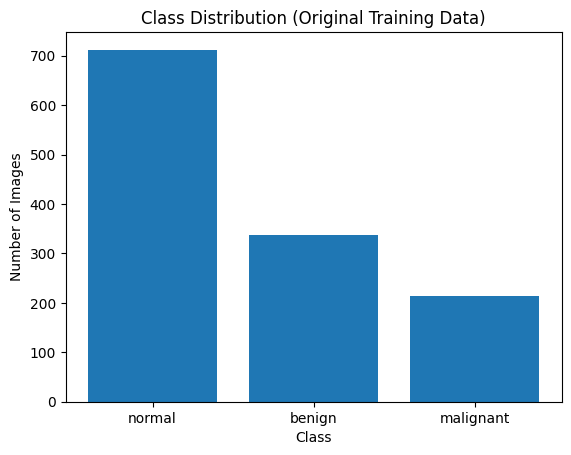

In [19]:
class_counts = np.bincount(y_train)

plt.figure()
plt.bar(classes, class_counts)
plt.title("Class Distribution (Original Training Data)")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

In [20]:
baseline_model = build_ds_cnn()

history = baseline_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=32
)

baseline_acc, baseline_prec, baseline_rec, baseline_f1, baseline_report = evaluate_model(baseline_model, X_test, y_test)

Epoch 1/10


I0000 00:00:1775223654.582990     131 service.cc:152] XLA service 0x7c0ee0015f00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775223654.583047     131 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1775223655.238521     131 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1775223663.466375     131 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


36/36 ━━━━━━━━━━━━━━━━━━━━ 28s 422ms/step - accuracy: 0.4899 - loss: 2.7409 - val_accuracy: 0.1811 - val_loss: 1.4568
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.7575 - loss: 0.9018 - val_accuracy: 0.1811 - val_loss: 2.0447
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.8334 - loss: 0.5091 - val_accuracy: 0.1811 - val_loss: 2.8572
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.8303 - loss: 0.4634 - val_accuracy: 0.1811 - val_loss: 3.8180
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.8905 - loss: 0.3011 - val_accuracy: 0.1811 - val_loss: 5.0911
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.8923 - loss: 0.2720 - val_accuracy: 0.1811 - val_loss: 5.7943
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9430 - loss: 0.1720 - val_accuracy: 0.1811 - val_loss: 7.8946
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9422 - loss: 0.1632 - val_accuracy: 0.1811 - val_loss: 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

# **2. APPLYING CLASS WEIGHTS**

In [21]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print("Class Weights:", class_weights) #These are class weights computed using the inbuilt function, based on the representation of each class in the whole dataset

Class Weights: {0: np.float64(0.5908239700374532), 1: np.float64(1.248269040553907), 2: np.float64(1.9749608763693272)}


In [22]:
weighted_model = build_ds_cnn()

history = weighted_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=32,
    class_weight=class_weights
)

weighted_acc, weighted_prec, weighted_rec, weighted_f1, weighted_report = evaluate_model(weighted_model, X_test, y_test)

Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 17s 265ms/step - accuracy: 0.4612 - loss: 2.4502 - val_accuracy: 0.1811 - val_loss: 1.3700
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.6738 - loss: 1.0402 - val_accuracy: 0.1811 - val_loss: 1.9013
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.7082 - loss: 0.7012 - val_accuracy: 0.1811 - val_loss: 2.5448
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.8158 - loss: 0.4166 - val_accuracy: 0.1811 - val_loss: 3.6557
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.8717 - loss: 0.2936 - val_accuracy: 0.1811 - val_loss: 4.7241
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.8978 - loss: 0.2203 - val_accuracy: 0.1811 - val_loss: 5.4615
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.9211 - loss: 0.2032 - val_accuracy: 0.1811 - val_loss: 6.5292
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.9541 - loss: 0.1517 - val_accuracy: 0.1811 -

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

# **3. DATA AUGMENTATION**

In [23]:
#Application of basic data augmentation limited to rotation, horizontal and vertical translations, zooming, and lastly, flipping
augmentor = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

In [24]:
X_aug = []
y_aug = []

class_counts = np.bincount(y_train)
max_count = np.max(class_counts)

for class_id in range(num_classes):
    imgs = X_train[y_train == class_id]
    needed = max_count - len(imgs)
    X_aug.extend(imgs)
    y_aug.extend([class_id]*len(imgs)) #Adding the augemented data to the original data

    if needed > 0:
        gen = augmentor.flow(imgs, batch_size=1)
        for _ in range(needed):
            img = next(gen)[0]
            X_aug.append(img)
            y_aug.append(class_id)

X_aug = np.array(X_aug)
y_aug = np.array(y_aug)

print("Original dataset:", X.shape)
print("Augmented dataset:", X_aug.shape)

Original dataset: (1578, 224, 224, 3)
Augmented dataset: (2136, 224, 224, 3)


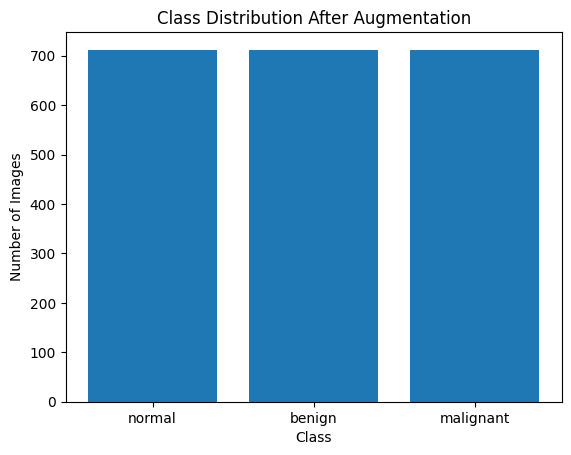

In [25]:
aug_counts = np.bincount(y_aug)

plt.figure()
plt.bar(classes, aug_counts)
plt.title("Class Distribution After Augmentation")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

In [26]:
aug_model = build_ds_cnn()

history = aug_model.fit(
    X_aug, y_aug,
    validation_split=0.1,
    epochs=10,
    batch_size=32
)

aug_acc, aug_prec, aug_rec, aug_f1, aug_report = evaluate_model(aug_model, X_test, y_test)

Epoch 1/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 23s 247ms/step - accuracy: 0.5690 - loss: 2.2362 - val_accuracy: 1.0000 - val_loss: 0.3195
Epoch 2/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.6991 - loss: 0.8617 - val_accuracy: 1.0000 - val_loss: 0.0494
Epoch 3/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.7988 - loss: 0.5375 - val_accuracy: 1.0000 - val_loss: 0.0095
Epoch 4/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.7979 - loss: 0.4868 - val_accuracy: 1.0000 - val_loss: 4.3772e-04
Epoch 5/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.8564 - loss: 0.3721 - val_accuracy: 1.0000 - val_loss: 5.9673e-05
Epoch 6/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.8705 - loss: 0.3744 - val_accuracy: 1.0000 - val_loss: 6.6963e-06
Epoch 7/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.8815 - loss: 0.3066 - val_accuracy: 1.0000 - val_loss: 3.2309e-07
Epoch 8/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.9186 - loss: 0.2230 - val_ac

# **4. SMOTE**

In [27]:
X_train_flat = X_train.reshape(len(X_train), -1)
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train_flat, y_train)
X_smote = X_smote.reshape(-1,224,224,3)

print("Original dataset:", X.shape)
print("SMOTE dataset:", X_smote.shape)

Original dataset: (1578, 224, 224, 3)
SMOTE dataset: (2136, 224, 224, 3)


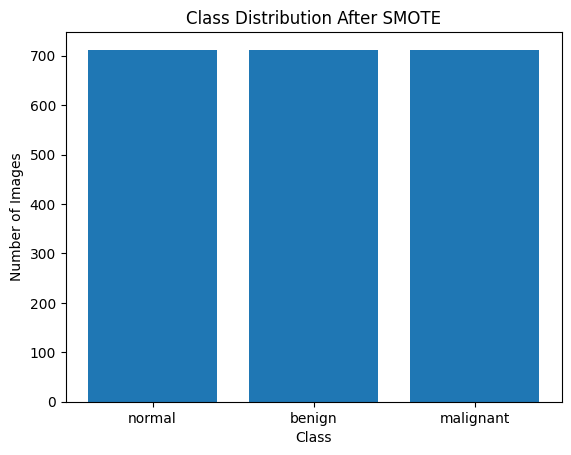

In [28]:
smote_counts = np.bincount(y_smote)

plt.figure()
plt.bar(classes, smote_counts)
plt.title("Class Distribution After SMOTE")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

In [29]:
smote_model = build_ds_cnn()

history = smote_model.fit(
    X_smote, y_smote,
    validation_split=0.1,
    epochs=10,
    batch_size=32
)

smote_acc, smote_prec, smote_rec, smote_f1, smote_report = evaluate_model(smote_model, X_test, y_test)

Epoch 1/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 18s 168ms/step - accuracy: 0.5725 - loss: 2.1820 - val_accuracy: 1.0000 - val_loss: 0.3687
Epoch 2/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.7613 - loss: 0.6563 - val_accuracy: 1.0000 - val_loss: 0.1278
Epoch 3/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.8093 - loss: 0.5125 - val_accuracy: 1.0000 - val_loss: 0.0152
Epoch 4/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.8915 - loss: 0.2860 - val_accuracy: 1.0000 - val_loss: 0.0027
Epoch 5/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.9224 - loss: 0.2137 - val_accuracy: 1.0000 - val_loss: 2.8415e-04
Epoch 6/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.9384 - loss: 0.1933 - val_accuracy: 1.0000 - val_loss: 1.5008e-05
Epoch 7/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.9339 - loss: 0.1920 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.9463 - loss: 0.1624 - val_accura

# **5. FOCAL LOSS**

In [30]:
def focal_loss(alpha=0.25, gamma=2.0):
    
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true = tf.one_hot(y_true, depth=num_classes)
        ce = tf.keras.losses.categorical_crossentropy(y_true, y_pred)
        p_t = tf.reduce_sum(y_true * y_pred, axis=-1)
        focal = alpha * tf.pow((1 - p_t), gamma) * ce
        return tf.reduce_mean(focal)
        
    return loss

focal_model = build_ds_cnn()

focal_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=focal_loss(alpha=0.25, gamma=2),
    metrics=['accuracy']
)

history = focal_model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=32
)

focal_acc, focal_prec, focal_rec, focal_f1, focal_report = evaluate_model(focal_model, X_test, y_test)

Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 18s 267ms/step - accuracy: 0.5055 - loss: 0.6463 - val_accuracy: 0.1811 - val_loss: 0.1769
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.7049 - loss: 0.2215 - val_accuracy: 0.1811 - val_loss: 0.2969
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.7572 - loss: 0.0987 - val_accuracy: 0.1811 - val_loss: 0.4463
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.8010 - loss: 0.0631 - val_accuracy: 0.1811 - val_loss: 0.6295
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.8382 - loss: 0.0452 - val_accuracy: 0.1811 - val_loss: 0.8449
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.8677 - loss: 0.0336 - val_accuracy: 0.1811 - val_loss: 1.0087
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.8724 - loss: 0.0289 - val_accuracy: 0.1811 - val_loss: 1.1495
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9093 - loss: 0.0201 - val_accuracy: 0.1811 -

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

# **RESULTS**

In [31]:
results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Class Weights",
        "Augmentation",
        "SMOTE",
        "Focal Loss"
    ],
    "Accuracy": [
        baseline_acc,
        weighted_acc,
        aug_acc,
        smote_acc,
        focal_acc
    ],
    "Precision": [
        baseline_prec,
        weighted_prec,
        aug_prec,
        smote_prec,
        focal_prec
    ],
    "Recall": [
        baseline_rec,
        weighted_rec,
        aug_rec,
        smote_rec,
        focal_rec
    ],
    "F1 Score": [
        baseline_f1,
        weighted_f1,
        aug_f1,
        smote_f1,
        focal_f1
    ]
})

display(results)

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline,0.167722,0.028131,0.167722,0.048180
1,Class Weights,0.167722,0.028131,0.167722,0.048180
2,Augmentation,0.449367,0.563444,0.449367,0.428112
3,SMOTE,0.496835,0.643697,0.496835,0.503769
4,Focal Loss,0.167722,0.028131,0.167722,0.048180


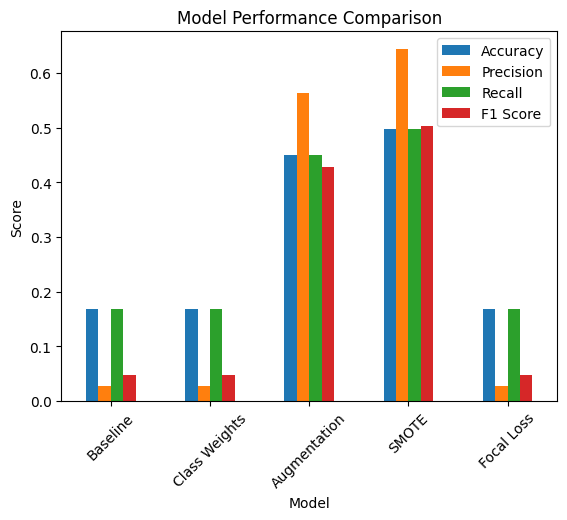

In [32]:
metrics = results.set_index("Model")

metrics.plot(kind="bar")
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

In [33]:
rows = []

models_reports = {
    "Baseline": (baseline_acc, baseline_prec, baseline_rec, baseline_f1, baseline_report),
    "Class Weights": (weighted_acc, weighted_prec, weighted_rec, weighted_f1, weighted_report),
    "Augmentation": (aug_acc, aug_prec, aug_rec, aug_f1, aug_report),
    "SMOTE": (smote_acc, smote_prec, smote_rec, smote_f1, smote_report),
    "Focal Loss": (focal_acc, focal_prec, focal_rec, focal_f1, focal_report)
}

for model_name, (acc, prec, rec, f1, report) in models_reports.items():
    for cls in classes:
        rows.append({
            "Model": model_name,
            "Accuracy": acc,
            "Overall Precision": prec,
            "Overall Recall": rec,
            "Overall F1": f1,
            "Class": cls,
            "Class Precision": report[cls]["precision"],
            "Class Recall": report[cls]["recall"],
            "Class F1": report[cls]["f1-score"]
        })

final_results = pd.DataFrame(rows)
display(final_results)

,Model,Accuracy,Overall Precision,Overall Recall,Overall F1,Class,Class Precision,Class Recall,Class F1
0,Baseline,0.167722,0.028131,0.167722,0.048180,normal,0.000000,0.000000,0.000000
1,Baseline,0.167722,0.028131,0.167722,0.048180,benign,0.000000,0.000000,0.000000
2,Baseline,0.167722,0.028131,0.167722,0.048180,malignant,0.167722,1.000000,0.287263
3,Class Weights,0.167722,0.028131,0.167722,0.048180,normal,0.000000,0.000000,0.000000
4,Class Weights,0.167722,0.028131,0.167722,0.048180,benign,0.000000,0.000000,0.000000
5,Class Weights,0.167722,0.028131,0.167722,0.048180,malignant,0.167722,1.000000,0.287263
6,Augmentation,0.449367,0.563444,0.449367,0.428112,normal,0.691176,0.262570,0.380567
7,Augmentation,0.449367,0.563444,0.449367,0.428112,benign,0.425926,0.547619,0.479167
8,Augmentation,0.449367,0.563444,0.449367,0.428112,malignant,0.350000,0.924528,0.507772
9,SMOTE,0.496835,0.643697,0.496835,0.503769,normal,0.690265,0.435754,0.534247


In [34]:
malignant_recall = {
    "Baseline": baseline_report["malignant"]["recall"],
    "Class Weights": weighted_report["malignant"]["recall"],
    "Augmentation": aug_report["malignant"]["recall"],
    "SMOTE": smote_report["malignant"]["recall"],
    "Focal Loss": focal_report["malignant"]["recall"]
}

pd.DataFrame.from_dict(malignant_recall, orient="index", columns=["Malignant Recall"])

,Malignant Recall
Baseline,1.000000
Class Weights,1.000000
Augmentation,0.924528
SMOTE,0.962264
Focal Loss,1.000000


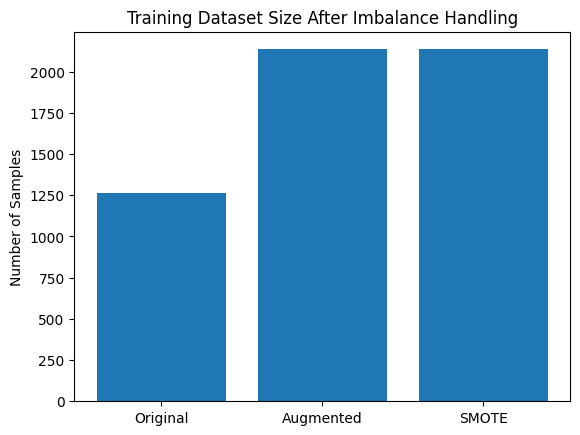

In [35]:
#Dataset size comparision

sizes = {
    "Original": len(X_train),
    "Augmented": len(X_aug),
    "SMOTE": len(X_smote)
}

plt.figure()
plt.bar(sizes.keys(), sizes.values())
plt.title("Training Dataset Size After Imbalance Handling")
plt.ylabel("Number of Samples")
plt.show()